# 02 Baseline

Цель: baseline без feature engineering: `LinearRegression` только на raw-признаках

In [10]:
from pathlib import Path
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path('..')
train_df = pd.read_csv(ROOT / 'data' / 'processed' / 'train_processed.csv')
val_df = pd.read_csv(ROOT / 'data' / 'processed' / 'val_processed.csv')
test_df = pd.read_csv(ROOT / 'data' / 'processed' / 'test_processed.csv')

In [11]:
target = 'nat_demand'
drop = [target, 'datetime', 'Datetime', 'date', 'Date', 'timestamp', 'Timestamp']
feats = [c for c in train_df.columns if c not in drop]
no_fe = ['hour', 'day_of_week', 'month', 'is_weekend', 'lag_1', 'lag_24', 'rolling_mean_24']
raw_feats = [c for c in feats if c not in no_fe]

x_train, y_train = train_df[raw_feats], train_df[target]
x_val, y_val = val_df[raw_feats], val_df[target]
x_test, y_test = test_df[raw_feats], test_df[target]

model = LinearRegression()
model.fit(x_train, y_train)
val_pred = model.predict(x_val)
test_pred = model.predict(x_test)

print('val_mae:', mean_absolute_error(y_val, val_pred))
print('val_rmse:', np.sqrt(mean_squared_error(y_val, val_pred)))
print('test_mae:', mean_absolute_error(y_test, test_pred))
print('test_rmse:', np.sqrt(mean_squared_error(y_test, test_pred)))

val_mae: 114.7831233347357
val_rmse: 139.73554951210104
test_mae: 137.1735010099145
test_rmse: 167.5248043572104


Этот baseline соответствует строке `baseline_raw_linear` в `report/experiments.csv`.

In [12]:
residuals = y_val - val_pred
print('mean residual:', float(residuals.mean()))
print('std residual:', float(residuals.std()))

mean residual: 68.05050136910391
std residual: 122.05417345433862


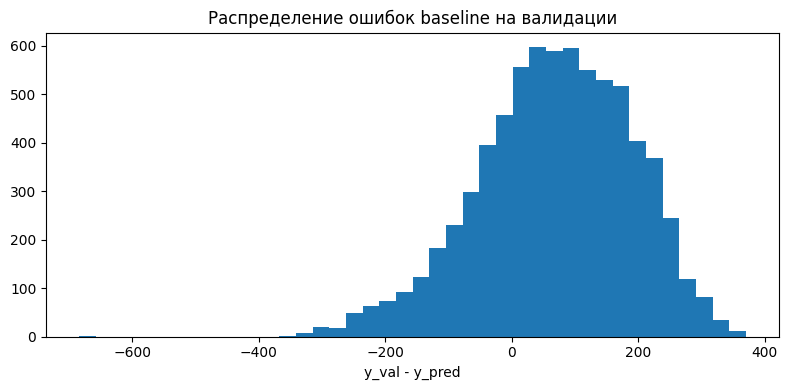

In [13]:
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=40)
plt.title('Распределение ошибок baseline на валидации')
plt.xlabel('y_val - y_pred')
plt.tight_layout()
plt.show()

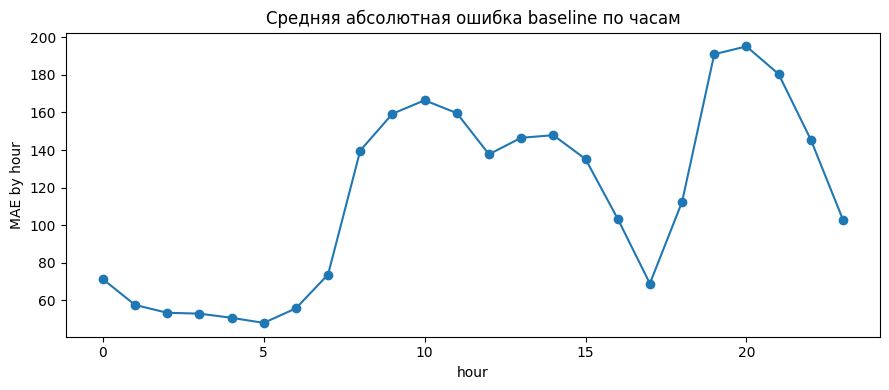

In [14]:
val_copy = val_df.copy()
val_copy['pred'] = val_pred
val_copy['abs_err'] = (val_copy[target] - val_copy['pred']).abs()

hourly_err = val_copy.groupby('hour')['abs_err'].mean()

plt.figure(figsize=(9, 4))
plt.plot(hourly_err.index, hourly_err.values, marker='o')
plt.title('Средняя абсолютная ошибка baseline по часам')
plt.xlabel('hour')
plt.ylabel('MAE by hour')
plt.tight_layout()
plt.show()

In [16]:
naive_pred = val_df['lag_1'].values
naive_mae = mean_absolute_error(y_val, naive_pred)
print('naive lag_1 val_mae:', naive_mae)
print('linear baseline val_mae:', mean_absolute_error(y_val, val_pred))

naive lag_1 val_mae: 46.16071961682632
linear baseline val_mae: 114.7831233347357


Вывод: baseline на raw-фичах слабый, даже простые временные зависимости  дают сильный сигнал, поэтому FE обязательно нужно

## Интерпретация

- Baseline без FE нужен как точка отсчета: он показывает, что модель на «сырых» признаках не справляется с динамикой нагрузки
- Распределение ошибок и разброс по часам показывают, что одна линейная связь не описывает поведение ряда